In [29]:
import matplotlib.pyplot as plt

DATA_FILE = "histograms/uniform.txt"

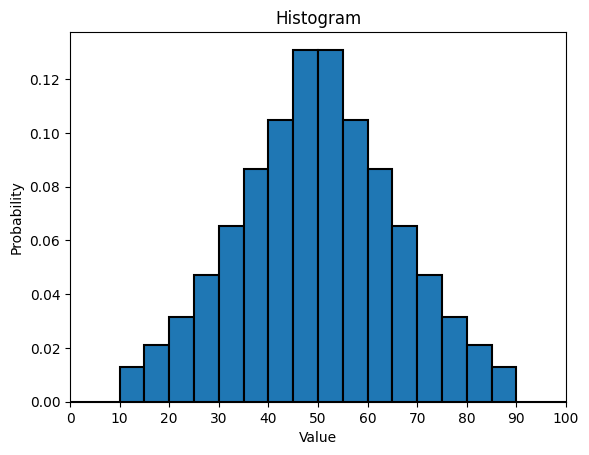

In [30]:
class Histogram:
    def __init__(self, bin_size):
        self.total_weight = 0
        self.bins = [0 for _ in range(int(100 / bin_size))]
        self.bin_size = bin_size

    def set_weight(self, bin_index, weight):
        if bin_index < 0 or bin_index >= len(self.bins):
            raise ValueError("Invalid bin index")

        self.total_weight -= self.bins[bin_index]
        self.bins[bin_index] = weight
        self.total_weight += weight

    def draw(self):
        x = [i * self.bin_size for i in range(len(self.bins))]
        heights = [w / self.total_weight for w in self.bins]
        plt.bar(x, heights, width=self.bin_size, align="edge", edgecolor="black", linewidth=1.5)
        plt.xlabel("Value")
        plt.ylabel("Probability")
        plt.title("Histogram")
        plt.xlim(min(x), max(x) + self.bin_size)
        plt.xticks([i * 10 for i in range(int(100 / 10) + 1)])
        plt.show()


hist = None
with open(DATA_FILE, "r") as f:
    bin_index = 0
    for line in f:
        if line.startswith("bucket_size: "):
            bucket_size = float(line.strip().split(" ")[1])
            hist = Histogram(bucket_size)
        else:
            weight = int(line.strip())
            hist.set_weight(bin_index, weight)
            bin_index += 1

hist.draw()